# Heart Disease UCI — Exploratory Data Analysis

**Dataset:** UCI Heart Disease, combined across all 4 original collection sites
(Cleveland, Hungary, Switzerland, VA Long Beach) — 920 raw rows, 13 clinical
features + a 0–4 severity target which we binarize to presence/absence of
disease.

Unlike the commonly-used 303-row Cleveland-only subset, this combined dataset
has substantial real missingness in several columns (e.g. `ca`, `thal`,
`slope`) because most non-Cleveland sites rarely recorded them. That
missingness is itself explored below and is handled explicitly in
`src/data/preprocess.py`.

Run `python data/download_data.py` then `python -m src.data.preprocess`
before executing this notebook.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import (
    BINARY_FEATURES, CATEGORICAL_FEATURES, NUMERIC_FEATURES,
    PROCESSED_DATA_PATH, TARGET_COL,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(PROCESSED_DATA_PATH)
print(df.shape)
df.head()

(918, 16)


,source,age,trestbps,chol,thalach,oldpeak,cp,restecg,slope,ca,thal,sex,fbs,exang,target_multiclass,target
0,cleveland,63.0,145.0,233.0,150.0,2.3,1.0,2.0,3.0,0.0,6.0,1.0,1.0,0.0,0,0
1,cleveland,67.0,160.0,286.0,108.0,1.5,4.0,2.0,2.0,3.0,3.0,1.0,0.0,1.0,2,1
2,cleveland,67.0,120.0,229.0,129.0,2.6,4.0,2.0,2.0,2.0,7.0,1.0,0.0,1.0,1,1
3,cleveland,37.0,130.0,250.0,187.0,3.5,3.0,0.0,3.0,0.0,3.0,1.0,0.0,0.0,0,0
4,cleveland,41.0,130.0,204.0,172.0,1.4,2.0,2.0,1.0,0.0,3.0,0.0,0.0,0.0,0,0


## 1. Missing data

Several features were only collected at some of the 4 sites. We visualize missingness before deciding how to impute.

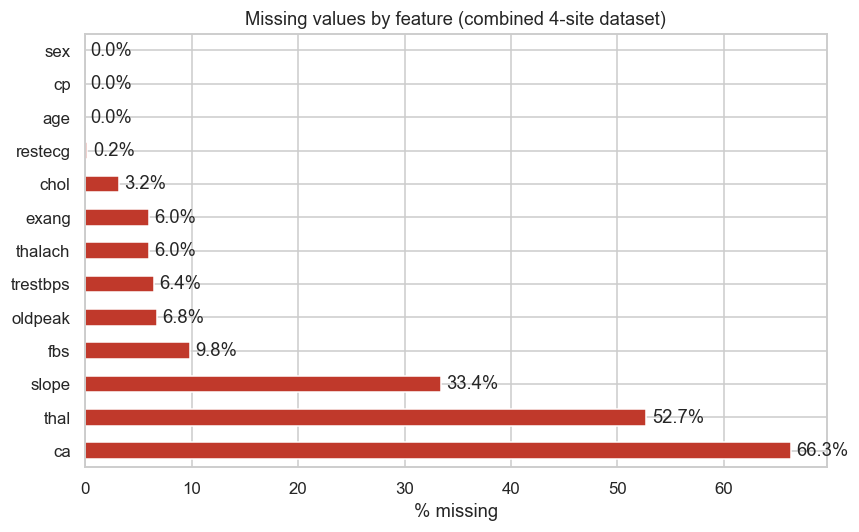

In [2]:
missing_pct = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
missing_pct.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("% missing")
ax.set_title("Missing values by feature (combined 4-site dataset)")
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig("../reports/screenshots/eda_missingness.png", bbox_inches="tight")
plt.show()

In [3]:
missing_by_source = df.assign(**{c: df[c].isna() for c in ["ca", "thal", "slope", "fbs"]}).groupby("source")[["ca", "thal", "slope", "fbs"]].mean() * 100
missing_by_source.style.background_gradient(cmap="Reds", axis=None).format("{:.0f}%")

,ca,thal,slope,fbs
source,,,,
cleveland,1%,1%,0%,0%
hungarian,99%,90%,65%,3%
switzerland,96%,42%,14%,61%
va_long_beach,99%,83%,51%,4%


**Observation:** `ca` and `thal` are almost entirely missing outside of Cleveland, and `slope`/`fbs` are missing for large parts of Switzerland/VA Long Beach. This drives the preprocessing decision to impute a distinct sentinel category for these fields rather than the mode, since "not recorded" is itself informative (site-correlated).

## 2. Target class balance

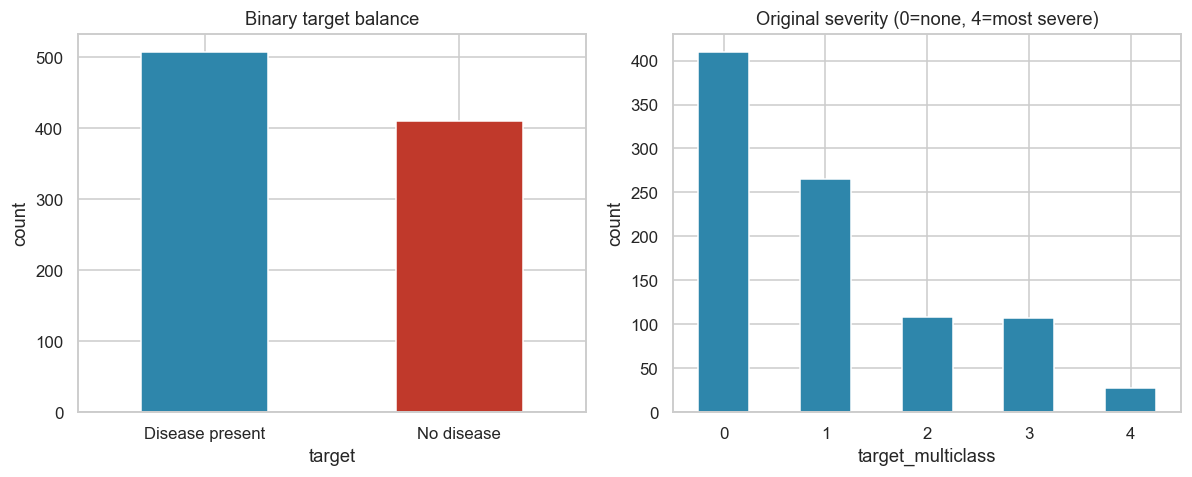

target
1    0.553
0    0.447
Name: proportion, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df[TARGET_COL].map({0: "No disease", 1: "Disease present"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2e86ab", "#c0392b"], rot=0
)
axes[0].set_title("Binary target balance")
axes[0].set_ylabel("count")

df["target_multiclass"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#2e86ab", rot=0
)
axes[1].set_title("Original severity (0=none, 4=most severe)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("../reports/screenshots/eda_class_balance.png", bbox_inches="tight")
plt.show()

df[TARGET_COL].value_counts(normalize=True).round(3)

The binary target is reasonably balanced (~55/45), so accuracy is a meaningful metric alongside ROC-AUC/precision/recall; no resampling is required.

## 3. Numeric feature distributions

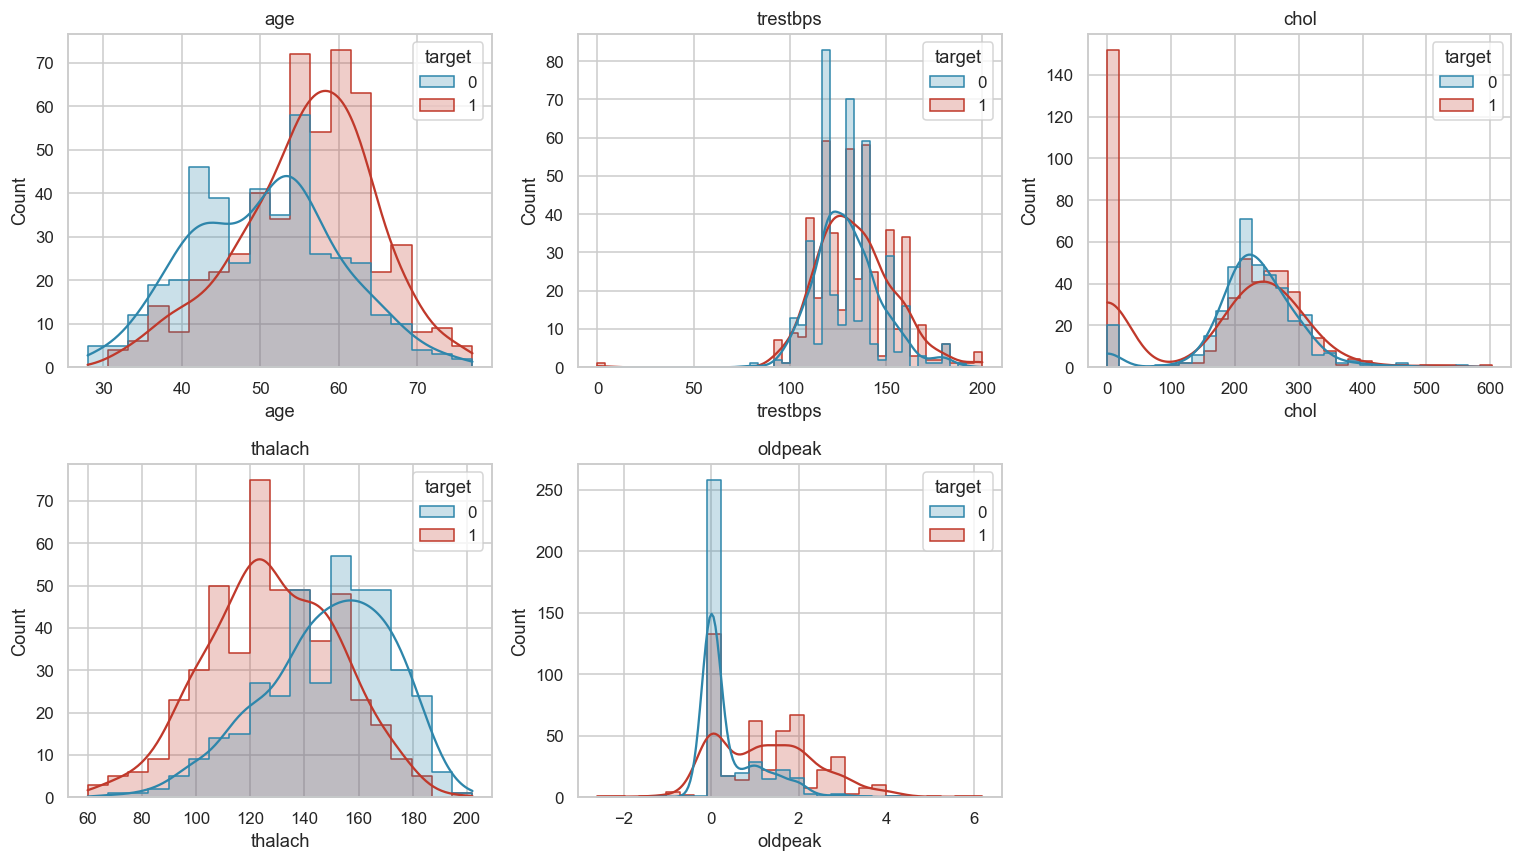

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, feat in enumerate(NUMERIC_FEATURES):
    sns.histplot(data=df, x=feat, hue=TARGET_COL, kde=True, ax=axes[i], palette=["#2e86ab", "#c0392b"], element="step")
    axes[i].set_title(feat)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/screenshots/eda_histograms.png", bbox_inches="tight")
plt.show()

## 4. Numeric features vs. target (boxplots)

/var/folders/55/47hf3ff54vl1gqfk5963lwn40000gn/T/ipykernel_60032/3636723470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=feat, ax=axes[i], palette=["#2e86ab", "#c0392b"])
/var/folders/55/47hf3ff54vl1gqfk5963lwn40000gn/T/ipykernel_60032/3636723470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y=feat, ax=axes[i], palette=["#2e86ab", "#c0392b"])
/var/folders/55/47hf3ff54vl1gqfk5963lwn40000gn/T/ipykernel_60032/3636723470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TA

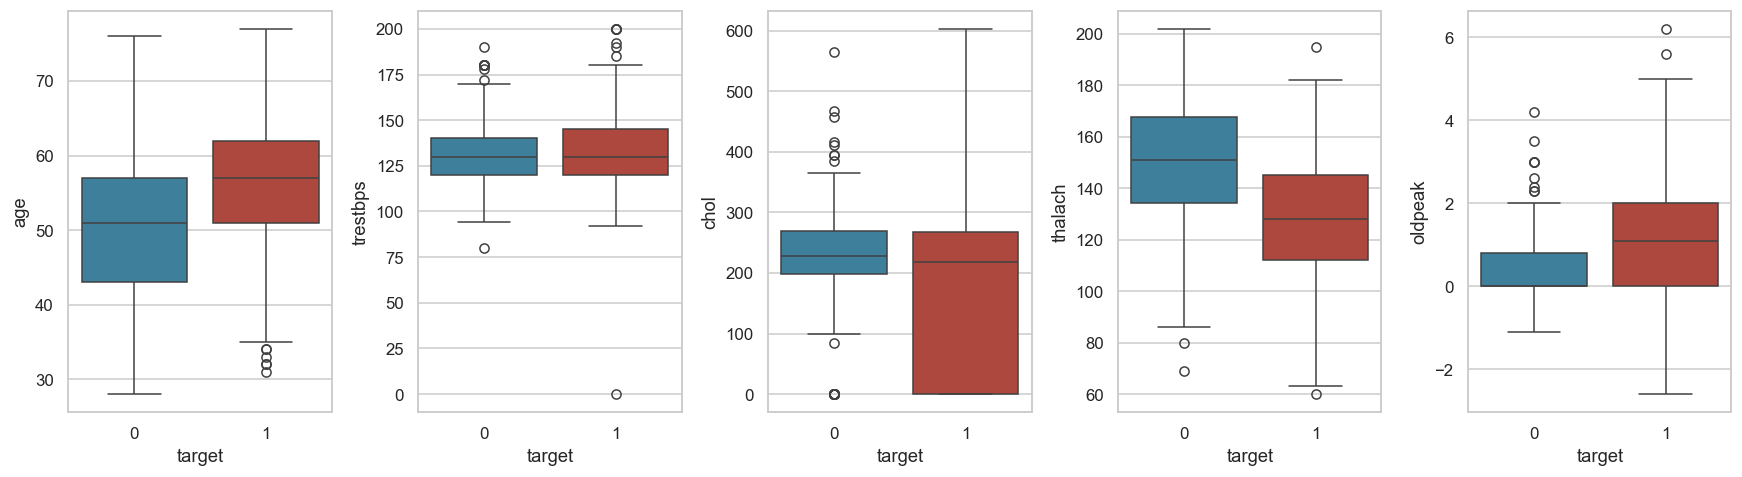

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))
for i, feat in enumerate(NUMERIC_FEATURES):
    sns.boxplot(data=df, x=TARGET_COL, y=feat, ax=axes[i], palette=["#2e86ab", "#c0392b"])
    axes[i].set_xlabel("target")
plt.tight_layout()
plt.savefig("../reports/screenshots/eda_boxplots.png", bbox_inches="tight")
plt.show()

## 5. Categorical feature distributions vs. target

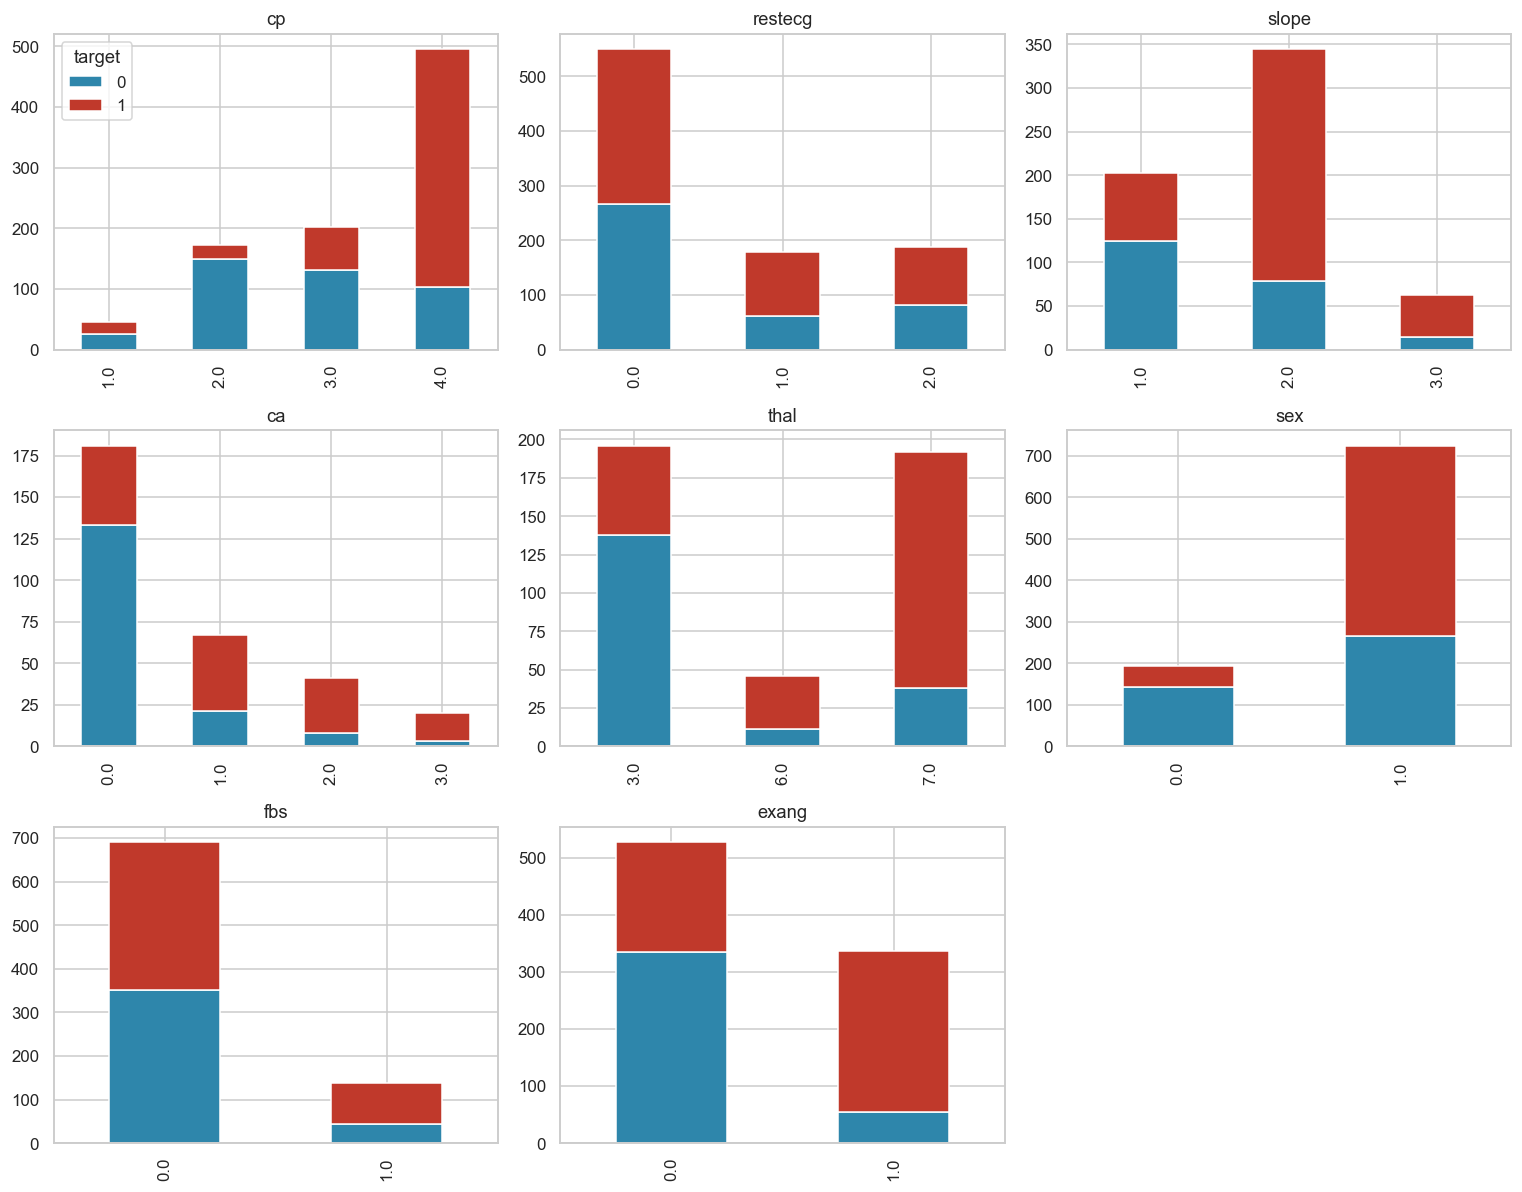

In [7]:
cat_feats = CATEGORICAL_FEATURES + BINARY_FEATURES
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for i, feat in enumerate(cat_feats):
    counts = df.groupby([feat, TARGET_COL]).size().unstack(fill_value=0)
    counts.plot(kind="bar", stacked=True, ax=axes[i], color=["#2e86ab", "#c0392b"], legend=(i == 0))
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
for j in range(len(cat_feats), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("../reports/screenshots/eda_categorical.png", bbox_inches="tight")
plt.show()

## 6. Correlation heatmap

Using pairwise-complete numeric correlations (NaNs excluded pairwise) plus the binary target.

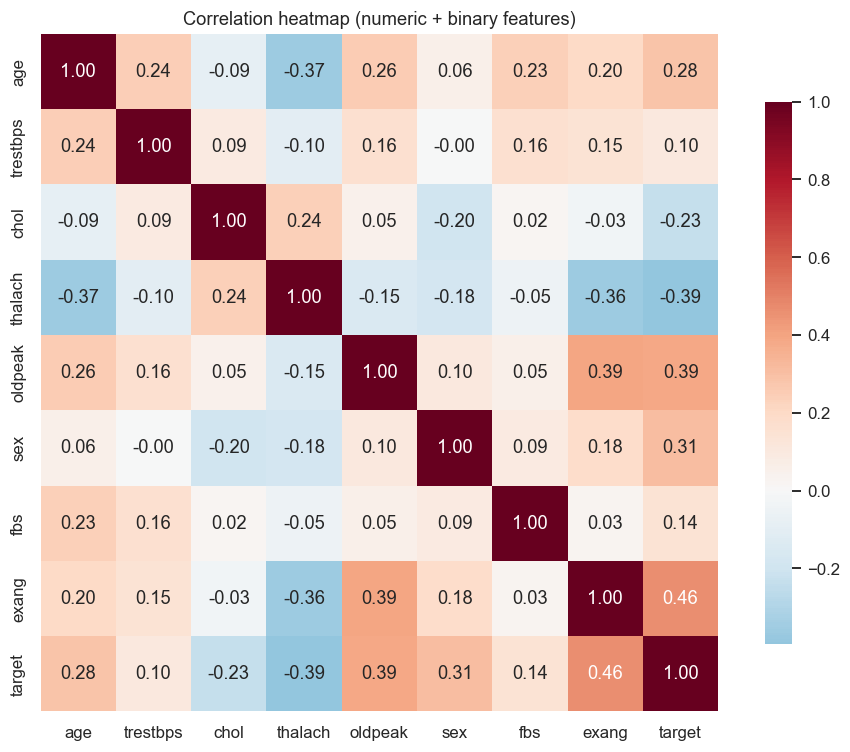

In [8]:
corr_cols = NUMERIC_FEATURES + BINARY_FEATURES + [TARGET_COL]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation heatmap (numeric + binary features)")
plt.tight_layout()
plt.savefig("../reports/screenshots/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 7. Key EDA takeaways

- The combined dataset (920 rows, 4 sites) is far messier than the standard Cleveland-only 303-row subset: `ca` (66%) and `thal` (53%) are missing for most non-Cleveland patients, and missingness is strongly site-correlated rather than random — this motivates the sentinel-category imputation used in `src/data/preprocess.py` instead of naive mean/mode fill.
- `thalach` (max heart rate achieved) is negatively associated with disease presence; `oldpeak` (ST depression) and `age` are positively associated — consistent with clinical literature.
- The binary target is reasonably balanced (55% / 45%), so no class-imbalance handling (e.g. SMOTE, class weighting) is required, though we still report precision/recall/ROC-AUC rather than accuracy alone.
- `exang` (exercise-induced angina) and `cp` (chest pain type) show visibly different distributions across target classes, flagging them as likely important predictors — confirmed later by feature importance in the Random Forest / Gradient Boosting models.